In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report,confusion_matrix

In [2]:
student=pd.read_csv("student_exam_performance_dataset (1).csv")

In [3]:
print(student.describe())

                age  study_hours_per_day  attendance_rate   sleep_hours  \
count  10000.000000         10000.000000     10000.000000  10000.000000   
mean      16.486900             3.019702        84.703770      7.018894   
std        1.122744             1.179235         9.509211      0.991714   
min       15.000000             0.500000        50.800000      4.000000   
25%       15.000000             2.200000        78.275000      6.337500   
50%       16.000000             3.010000        85.100000      7.030000   
75%       17.000000             3.830000        91.900000      7.690000   
max       18.000000             7.240000       100.000000     10.000000   

       social_media_hours  assignment_completion_rate  participation_score  \
count         10000.00000                10000.000000          10000.00000   
mean              2.51730                   79.491450             69.81681   
std               1.44675                   13.763237             14.65927   
min         

In [4]:
print(student.shape)

(10000, 23)


In [5]:
print(student.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  str    
 1   gender                      10000 non-null  str    
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  str    
 4   family_income               10000 non-null  str    
 5   internet_access             10000 non-null  str    
 6   study_environment           10000 non-null  str    
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    10000 non-null 

In [6]:
print(student.isnull().sum())

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
dtype: int64


In [7]:
# cleaning data
object=LabelEncoder()
student["gender"]=object.fit_transform(student["gender"])#1 for male 0 for female

In [8]:
student["internet_access"]=object.fit_transform(student["internet_access"])
student["tutoring"]=object.fit_transform(student["tutoring"])
student["pass_fail"]=object.fit_transform(student["pass_fail"])
# student["tutoring"]=student["tutoring"].astype(int)
student["student_id"]=np.arange(0,10000,1)
student=pd.get_dummies(student,columns=["parental_education","family_income","study_environment","grade_category"],dtype=int)

Classification report=
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      1.00      1.00      1160

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



c:\Users\hp\Desktop\studentSuccessPredictor\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


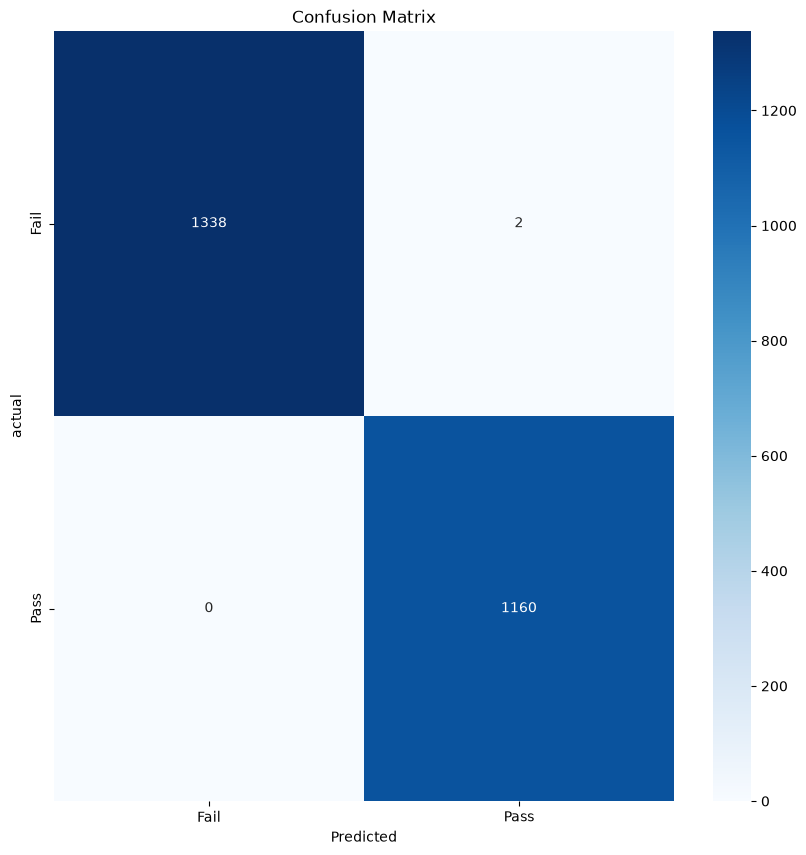

Prediction based on input::Pass


c:\Users\hp\Desktop\studentSuccessPredictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [9]:
# feature scaling
scaler=StandardScaler()

student_scaled=student.copy()

student_scaled[["study_hours_per_day","attendance_rate","assignment_completion_rate","final_exam_score","sleep_hours"]]=scaler.fit_transform(student[["study_hours_per_day","attendance_rate","assignment_completion_rate","final_exam_score","sleep_hours"]])

X=pd.DataFrame(student_scaled[["study_hours_per_day","attendance_rate","assignment_completion_rate","final_exam_score","sleep_hours"]])#feature

y=pd.DataFrame(student["pass_fail"])#target


X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.75,random_state=42)

model=LogisticRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Classification report=\n",classification_report(y_test,y_pred))

confusion=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,10))

sns.heatmap(confusion,annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.xlabel("Predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix")
plt.show()

try:
    study_hours_per_day=float(input("Enter routine self study hours"))
    attendance_rate=float(input("Enter attendance percentage"))
    assignment_completion_rate=float(input("Enter assignment completed percentage"))
    final_exam_score=float(input("Enter total final score int past out of 100"))
    sleep_hours=float(input("Enter routine sleep hours"))

    user_data={
        "study_hours_per_day":[study_hours_per_day],
        "attendance_rate":[attendance_rate],
        "assignment_completion_rate":[assignment_completion_rate],
        "final_exam_score":[final_exam_score],
        "sleep_hours":[sleep_hours]
    }

    user=pd.DataFrame(user_data)
    user_scaled=scaler.transform(user)
    predicted_result=model.predict(user_scaled)[0]

    if predicted_result==1:
        print(f"Prediction based on input::Pass")
    else:
        print(f"Prediction based on input::Fail")

except Exception as e:
    print("An error occured",e)

In [10]:
import joblib

joblib.dump(model,"model.pkl")

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']